# 3 — RESTORE: per-image marker positivity

RESTORE as the manuscript describes it, on the frozen biological pairs.

The per-cell feature is the **Membrane / Cytoplasm ratio**. Membrane and Cytoplasm are disjoint
regions and the membrane mean runs above the cytoplasm mean, so the ratio measures how far a marker
is pushed to the membrane relative to that same cell's interior — self-normalising per cell, so it
does not carry the cell's overall brightness.

A cell needs both a nucleus and a cell body to have a cytoplasm; cells without one are dropped.
Every cell, no subsampling, no clipping.

**These are RAW QuPath compartment means, not REDSEA.** `qupath_compartment_full_20donor` was
extracted from the QuPath measurement CSVs, which are pre-REDSEA: `Cell__<marker>` matches
`data/cells` at r=1.000000 (max delta 5e-05) and `data/cells_redsea` at r=0.974 (max delta 12,816).
REDSEA emits a corrected whole-cell mean only — there is no REDSEA-corrected Nucleus, Cytoplasm or
Membrane.


## 1 — Load Cytoplasm and Membrane for every cell



In [ ]:
import sys, glob, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
%matplotlib inline
warnings.filterwarnings('ignore')


In [2]:
REPO    = pathlib.Path.cwd().resolve().parents[1]     # Islet-Explorer-Senior (data/ lives here)
COMPART = REPO/'data'/'restore_pair_validation'/'qupath_compartment_full_20donor'
REDSEA  = REPO/'data'/'cells_redsea'

DONOR  = '6566'
MARKER = 'CD11b'

print('donor', DONOR, '| marker', MARKER)


donor 6566 | marker CD11b


In [3]:
f = glob.glob(str(COMPART/f'donor_id={DONOR}'/'*.parquet'))[0]
cy, mb = f'Cytoplasm__{MARKER}', f'Membrane__{MARKER}'
d = pd.read_parquet(f, columns=['object_id', cy, mb])
n_all = len(d)

# a cell needs both a nucleus and a cell body to have a cytoplasm
keep = np.isfinite(d[cy]) & np.isfinite(d[mb]) & (d[cy] >= 0) & (d[mb] >= 0)
d = d[keep].reset_index(drop=True)
C = d[cy].to_numpy(float)
M = d[mb].to_numpy(float)
print(f'{n_all:,} cells   ->  {len(d):,} with a cytoplasm   ({n_all-len(d):,} dropped)')
print(f'  Cytoplasm  median {np.median(C):8.1f}   max {C.max():9.1f}')
print(f'  Membrane   median {np.median(M):8.1f}   max {M.max():9.1f}')



1,781,276 cells   ->  1,621,163 with a cytoplasm   (160,113 dropped)
  Cytoplasm  median    654.5   max   44908.7
  Membrane   median    646.6   max   34961.4


## 2 — The two distributions



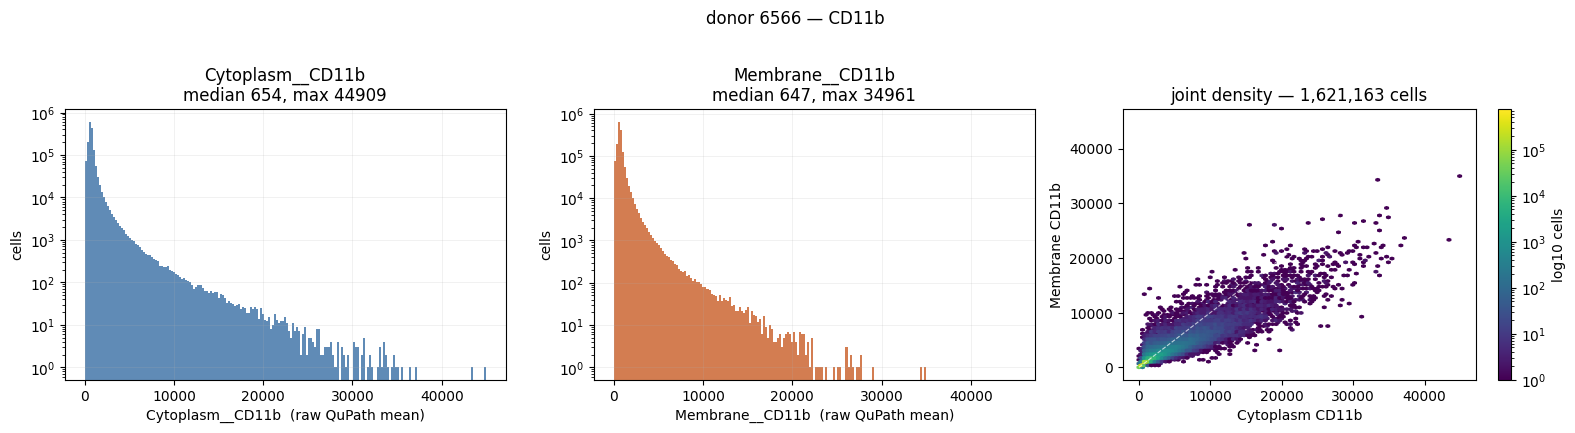

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# --- the two compartment distributions, linear intensity, log counts ----------------------------
bins = np.linspace(0, max(C.max(), M.max()), 200)
for a, (nm, x, colr) in zip(ax[:2], ((cy, C, '#4477AA'), (mb, M, '#CC6633'))):
    a.hist(x, bins=bins, color=colr, alpha=.85)
    a.set_yscale('log')
    a.set_xlabel(f'{nm}  (raw QuPath mean)'); a.set_ylabel('cells')
    a.set_title(f'{nm}\nmedian {np.median(x):.0f}, max {x.max():.0f}')
    a.grid(alpha=.25, lw=.5)

# --- the joint density: where a cell sits in both compartments at once --------------------------
hb = ax[2].hexbin(C, M, gridsize=90, bins='log', cmap='viridis', mincnt=1)
lim = [0, max(C.max(), M.max())]
ax[2].plot(lim, lim, color='w', lw=.8, ls='--', alpha=.7)
ax[2].set_xlabel(f'Cytoplasm {MARKER}'); ax[2].set_ylabel(f'Membrane {MARKER}')
ax[2].set_title(f'joint density — {len(C):,} cells')
fig.colorbar(hb, ax=ax[2], label='log10 cells')

fig.suptitle(f'donor {DONOR} — {MARKER}', y=1.02)
plt.tight_layout(); plt.show()


## 3 — The ratio


1,621,156 cells with a usable ratio   (7 dropped: Cytoplasm 0)
  median 0.984   IQR 0.920-1.046   max 62.5


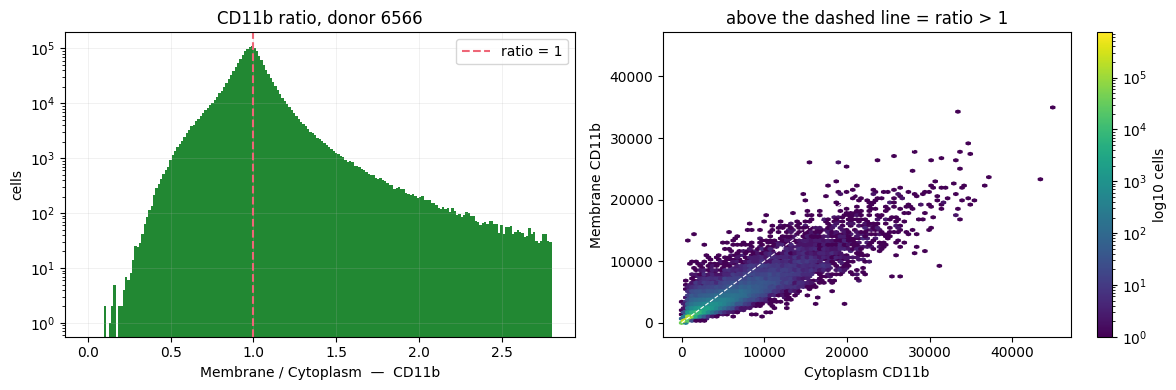

In [10]:
RATIO = M / np.where(C > 0, C, np.nan)      # Membrane / Cytoplasm, per cell
good  = np.isfinite(RATIO)
print(f'{good.sum():,} cells with a usable ratio   ({(~good).sum():,} dropped: Cytoplasm 0)')
print(f'  median {np.nanmedian(RATIO):.3f}   IQR {np.nanpercentile(RATIO,25):.3f}-{np.nanpercentile(RATIO,75):.3f}   max {np.nanmax(RATIO):.1f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(RATIO[good], bins=np.linspace(0, np.nanpercentile(RATIO, 99.9), 200), color='#228833')
ax[0].set_yscale('log'); ax[0].axvline(1.0, color='#EE6677', lw=1.5, ls='--', label='ratio = 1')
ax[0].set_xlabel(f'Membrane / Cytoplasm  —  {MARKER}'); ax[0].set_ylabel('cells'); ax[0].legend()
ax[0].set_title(f'{MARKER} ratio, donor {DONOR}'); ax[0].grid(alpha=.25, lw=.5)
hb = ax[1].hexbin(C, M, gridsize=90, bins='log', cmap='viridis', mincnt=1)
lim = [0, max(C.max(), M.max())]; ax[1].plot(lim, lim, color='w', lw=.8, ls='--')
ax[1].set_xlabel(f'Cytoplasm {MARKER}'); ax[1].set_ylabel(f'Membrane {MARKER}')
ax[1].set_title('above the dashed line = ratio > 1'); fig.colorbar(hb, ax=ax[1], label='log10 cells')
plt.tight_layout(); plt.show()


## 4 — The biological pair

RESTORE works on a **mutually exclusive pair** (i, j). The pairs are chosen biologically, not
algorithmically — `restore_validation.ACCEPTED_PAIRS` is the frozen set. `Y` is the n x 2 profile of
the pair, here in ratio space.

Only pairs whose **both** markers have compartment measurements can be run: 10 of the 24.


In [ ]:
from phenocycler.restore_validation import ACCEPTED_PAIRS
have = {c.split('__',1)[1] for c in pd.read_parquet(f).columns if c.startswith('Membrane__')}
pairs = [(t, r) for t, r in ACCEPTED_PAIRS if t in have and r in have]
print(f'{len(pairs)} of {len(ACCEPTED_PAIRS)} accepted pairs have compartment data:')
for t, r in pairs: print(f'    {t} <- {r}')

TARGET, REFERENCE = MARKER, 'EpCAM'         # set the pair to run
assert (TARGET, REFERENCE) in pairs, f'{TARGET} <- {REFERENCE} is not an accepted pair with compartments'



In [ ]:
def ratio(frame, marker):
    c = frame[f'Cytoplasm__{marker}'].to_numpy(float)
    m = frame[f'Membrane__{marker}'].to_numpy(float)
    return m / np.where(c > 0, c, np.nan)


def drop_top_outliers(*arrays, q=99.9):
    """Mask out cells in the extreme upper tail of ANY of the supplied arrays.

    A handful of cells with a tiny cytoplasm produce enormous ratios and stretch every axis and every
    cluster fit. Returns a boolean keep-mask; `q` is the percentile above which a cell is dropped.
    Set q=100 to keep everything."""
    keep = np.ones(len(arrays[0]), dtype=bool)
    for a in arrays:
        finite = np.isfinite(a)
        cut = np.nanpercentile(a[finite], q) if q < 100 else np.inf
        keep &= finite & (a <= cut)
    return keep


OUTLIER_Q = 99.9        # percentile above which a cell is dropped; 100 = keep everything

full = pd.read_parquet(f)
yi, yj = ratio(full, TARGET), ratio(full, REFERENCE)
ok = drop_top_outliers(yi, yj, q=OUTLIER_Q)
Y  = np.column_stack([yi[ok], yj[ok]])
ids = full['object_id'].astype(str).to_numpy()[ok]
n_finite = int((np.isfinite(yi) & np.isfinite(yj)).sum())
print(f'{n_finite:,} cells with both ratios   ->  {ok.sum():,} kept '
      f'({n_finite - ok.sum():,} dropped above the {OUTLIER_Q} pct)')
print(f'  {TARGET:16s} max {np.nanmax(yi):10.1f}  ->  {Y[:,0].max():8.3f}')
print(f'  {REFERENCE:16s} max {np.nanmax(yj):10.1f}  ->  {Y[:,1].max():8.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5))
hb = ax.hexbin(Y[:,0], Y[:,1], gridsize=100, bins='log', cmap='viridis', mincnt=1)
ax.set_xlabel(f'{TARGET} ratio'); ax.set_ylabel(f'{REFERENCE} ratio')
ax.set_title(f'{TARGET} <- {REFERENCE}, donor {DONOR}')
fig.colorbar(hb, ax=ax, label='log10 cells'); plt.tight_layout(); plt.show()


## 5 — Two groups

Lemma 1: for a mutually exclusive pair the groups cannot be written as positive combinations of one
another, so a 2-group clustering separates them. The manuscript uses SSC; NNMF and GMM are named as
alternatives.

The group with the **lower target ratio** is target-negative — that is the negative control for the
target marker.


In [ ]:
from sklearn import mixture
lab = mixture.GaussianMixture(2, covariance_type='full', n_init=5, random_state=0).fit_predict(Y)
means = [Y[lab == g, 0].mean() for g in (0, 1)]
control = int(np.argmin(means))            # lower target ratio == target-negative
is_ctrl = lab == control
print(f'group 0: n={int((lab==0).sum()):>9,}   mean {TARGET} ratio {means[0]:.3f}')
print(f'group 1: n={int((lab==1).sum()):>9,}   mean {TARGET} ratio {means[1]:.3f}')
print(f'\nnegative control = group {control}  ({is_ctrl.sum():,} cells)')

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(Y[is_ctrl,0], Y[is_ctrl,1], s=1, c='#4477AA', alpha=.2, label='negative control')
ax.scatter(Y[~is_ctrl,0], Y[~is_ctrl,1], s=1, c='#CC6633', alpha=.2, label='other group')
ax.set_xlabel(f'{TARGET} ratio'); ax.set_ylabel(f'{REFERENCE} ratio')
ax.set_title(f'{TARGET} <- {REFERENCE}'); ax.legend(markerscale=8); plt.tight_layout(); plt.show()


## 6 — Background level, and the call

The manuscript takes the background as the **maximum** of the target over the negative control
(`b = max(b_i,k)`), then divides. Normalised controls are <= 1 by construction and signal is > 1.


In [ ]:
B = float(Y[is_ctrl, 0].max())
norm = Y[:, 0] / B
is_pos = norm > 1.0
print(f'background B = max {TARGET} ratio over the control = {B:.3f}')
print(f'positive: {is_pos.sum():,} cells  ({is_pos.mean()*100:.4f}% of {len(norm):,})')

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(norm, bins=np.linspace(0, np.percentile(norm, 99.99), 250), color='#777')
ax.axvline(1.0, color='#EE6677', lw=2, label='B (controls <= 1)')
ax.set_yscale('log'); ax.set_xlabel(f'{TARGET} ratio / B'); ax.set_ylabel('cells')
ax.set_title(f'{TARGET} <- {REFERENCE}, donor {DONOR}: {is_pos.sum():,} positive'); ax.legend()
plt.tight_layout(); plt.show()


## 7 — Write the calls for QuPath

Import with `scripts/groovy/import_broad_lineage.groovy`, which matches on the QuPath detection UUID.


In [ ]:
outdir = REPO/'data'/'positivity'/TARGET
outdir.mkdir(parents=True, exist_ok=True)
out = pd.DataFrame({'object_id': ids, f'{TARGET}_ratio': Y[:,0],
                    f'{REFERENCE}_ratio': Y[:,1], f'{TARGET}_norm': norm,
                    f'{TARGET}_pos': is_pos})
dst = outdir/f'{TARGET}_from_{REFERENCE}_{DONOR}.csv'
out.to_csv(dst, index=False)
print(f'{dst}\n{is_pos.sum():,} positive of {len(out):,}')
out[out[f'{TARGET}_pos']].head()


## 8 — Every accepted pair with compartment data, this donor


In [ ]:
rows = []
for t, r in pairs:
    a, b = ratio(full, t), ratio(full, r)
    k = drop_top_outliers(a, b, q=OUTLIER_Q)
    Yp = np.column_stack([a[k], b[k]])
    lb = mixture.GaussianMixture(2, covariance_type='full', n_init=3, random_state=0).fit_predict(Yp)
    ctrl = int(np.argmin([Yp[lb==g,0].mean() for g in (0,1)]))
    Bp = float(Yp[lb==ctrl,0].max())
    n  = int((Yp[:,0] > Bp).sum())
    rows.append(dict(target=t, reference=r, n_cells=len(Yp), control_n=int((lb==ctrl).sum()),
                     B=round(Bp,3), n_positive=n, pct=round(n/len(Yp)*100, 4)))
    print(f'  {t:16s} <- {r:16s}  B={Bp:8.3f}  {n:>8,} positive', flush=True)
per_pair = pd.DataFrame(rows)
per_pair

